# Etapa 3 — Modelagem

Entrada: `../data/processed/dataset.csv`, da Etapa 2.
Saída: um classificador treinado, avaliado e interpretado, e um ranking dos
melhores horários da janela.

Um detalhe que define esta etapa: **não existe label pronta.** O site
classifica as condições para pesca, não para surf — e pesca gosta de mar
calmo, quase o oposto. Definir o que é uma condição boa para surfar é a
primeira tarefa aqui, e é uma decisão sua.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

DIR_PROC = Path("..") / "data" / "processed"

## 1. Carregar o dataset processado

Confira que veio o que você espera: número de linhas, tipos, nulos. Se a
Etapa 2 mudou, isso aparece aqui.

In [2]:
df = pd.read_csv(DIR_PROC / "dataset.csv", parse_dates=["datetime"])
df["dia"] = df["datetime"].dt.date
print(df.shape, "nulos:", df.isna().sum().sum())

(168, 10) nulos: 0


Vieram as 168 horas, sem nulos.

## 2. Definir a label

Escreva, em código, a regra que separa condições ruins, boas e ótimas (ou
outro conjunto de classes, se preferir).

- Quais variáveis entram na regra: altura da onda, vento, maré, direção?
- Quais limiares? De onde vem o número — leitura, conversa com surfista,
  distribuição dos próprios dados? Registre a origem, mesmo que seja um chute
  informado.
- Como as classes ficaram distribuídas? Se 95% das horas caírem numa classe,
  a métrica do modelo vai mentir para você.

Documente a regra em markdown antes de seguir. Tudo depois disso depende dela.

Cada hora ganha pontos pela onda e pelo vento:

| Variável | Pontos |
|---|---|
| Onda | 2 se `>= 1,3 m`, 1 se `>= 1,1 m`, 0 abaixo |
| Vento | 2 se `<= 19 km/h`, 1 se `<= 23 km/h`, 0 acima |

A soma dá a classe: **ruim** (0 a 1), **boa** (2) e **ótima** (3 ou 4).

Os limiares são um chute meu, sem referência de surfista. Escolhi olhando os dados, para as classes não ficarem muito desiguais. A ideia é que onda maior e vento mais fraco são melhores. Maré e direção ficaram de fora da regra.

In [3]:
def pontuar(linha):
    pontos = 0

    if linha["altura_onda_m"] >= 1.3:
        pontos += 2
    elif linha["altura_onda_m"] >= 1.1:
        pontos += 1

    if linha["vento_kmh"] <= 19:
        pontos += 2
    elif linha["vento_kmh"] <= 23:
        pontos += 1

    return pontos

df["pontos"] = df.apply(pontuar, axis=1)
df["classe"] = pd.cut(df["pontos"], bins=[-1, 1, 2, 4], labels=["ruim", "boa", "otima"])
df["classe"].value_counts()

classe
ruim     83
boa      54
otima    31
Name: count, dtype: int64

As classes ficaram em 83 ruins, 54 boas e 31 ótimas, sem nenhuma dominando.

## 3. Features e alvo

Separe `X` e `y`.

- Quais colunas entram como feature? Cuidado: usar diretamente as variáveis da
  sua regra faz o modelo apenas redescobrir o `if` que você escreveu. Isso é
  esperado aqui — mas você precisa saber que é isso que está acontecendo.
- Direção do vento e da onda são texto. Como transformar em número sem inventar
  uma ordem que não existe?

In [4]:
FEATURES = ["altura_onda_m", "vento_kmh", "mare_m", "mare_subindo", "hora"]
X = df[FEATURES]
y = df["classe"].astype(str)

As features são onda, vento, maré e hora. A direção ficou de fora porque é quase sempre a mesma (do mar para a terra). Como onda e vento estão na regra, o modelo vai principalmente redescobrir a regra.

## 4. Treino e teste

Divida os dados. Vale estratificar pelas classes? A ordem temporal importa —
sortear linhas de um mesmo dia entre treino e teste vaza informação?

In [5]:
dias_teste = [pd.Timestamp("2026-10-11").date(), pd.Timestamp("2026-10-13").date()]
teste = df["dia"].isin(dias_teste)

X_treino, y_treino = X[~teste], y[~teste]
X_teste, y_teste = X[teste], y[teste]
print(len(X_treino), len(X_teste))

120 48


Separei por dia, e não por linha, porque horas vizinhas são quase iguais. O teste usa 11 e 13/10 e o treino usa os outros cinco dias.

## 5. Treinar

Treine pelo menos dois modelos de famílias diferentes (por exemplo uma árvore
e um modelo baseado em distância) para ter com o que comparar.

In [6]:
arvore = DecisionTreeClassifier(max_depth=4, random_state=0)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))

arvore.fit(X_treino, y_treino)
knn.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['boa','otima','ruim']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['altura_onda_m','vento_kmh','mare_m','mare_subindo','hora']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 6. Avaliar

- Acurácia é suficiente aqui, com as classes desbalanceadas como estão?
- Olhe a matriz de confusão: que erro o modelo comete?
- Um único split é confiável com poucas linhas, ou vale validação cruzada?

Árvore acurácia: 0.98
KNN acurácia: 0.96
sempre 'ruim': 0.6


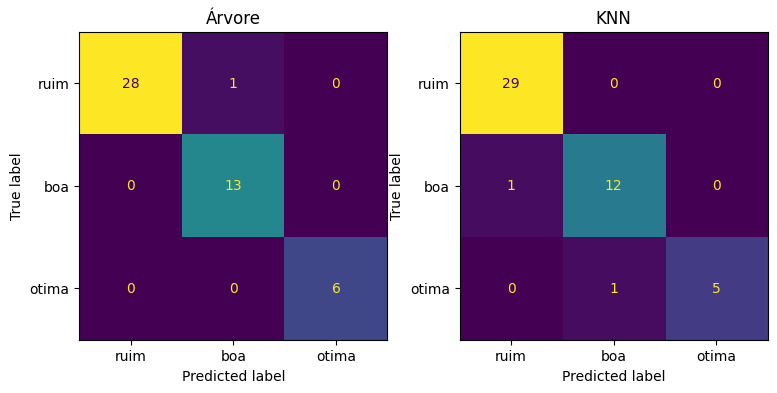

In [7]:
ordem = ["ruim", "boa", "otima"]
fig, eixos = plt.subplots(1, 2, figsize=(9, 4))

for eixo, nome, modelo in [(eixos[0], "Árvore", arvore), (eixos[1], "KNN", knn)]:
    previsao = modelo.predict(X_teste)
    print(nome, "acurácia:", round(accuracy_score(y_teste, previsao), 2))
    ConfusionMatrixDisplay.from_predictions(y_teste, previsao, labels=ordem, ax=eixo, colorbar=False)
    eixo.set_title(nome)

maioria = y_treino.value_counts().idxmax()
print(f"sempre '{maioria}':", round((y_teste == maioria).mean(), 2))
plt.show()

Sempre chutar "ruim" acerta 60%. A árvore acerta 98% e o KNN 96%, e os dois erram pouquíssimas horas. A acurácia é alta porque a classe vem direto da onda e do vento, e o modelo só aprendeu a regra.

## 7. Interpretar

Um modelo que acerta e você não sabe por quê não serve para responder nada.

- Plote a árvore. Os cortes que ela encontrou parecem com os seus limiares?
- Quais features o modelo considera mais importantes? Bate com sua intuição?
- Se a acurácia veio altíssima, explique o motivo — não celebre.

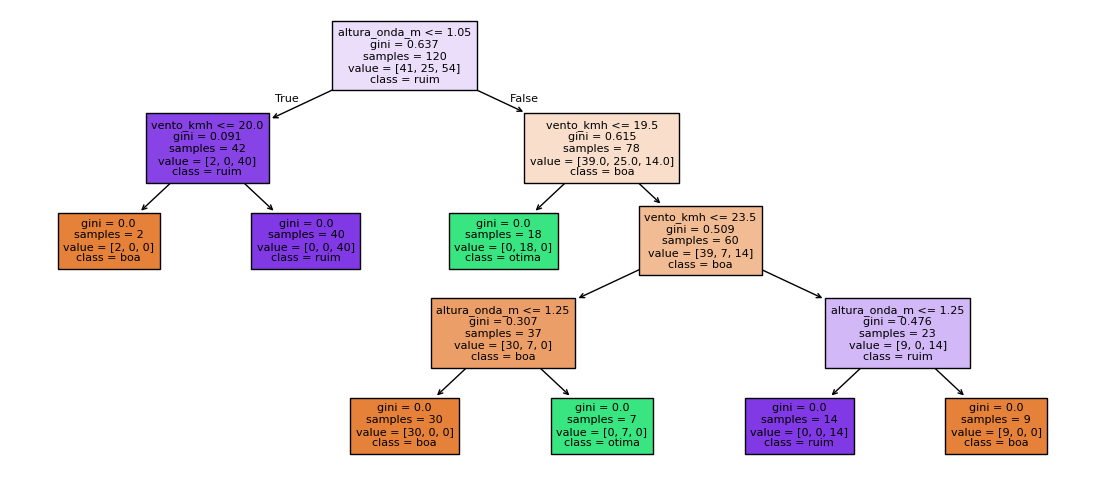

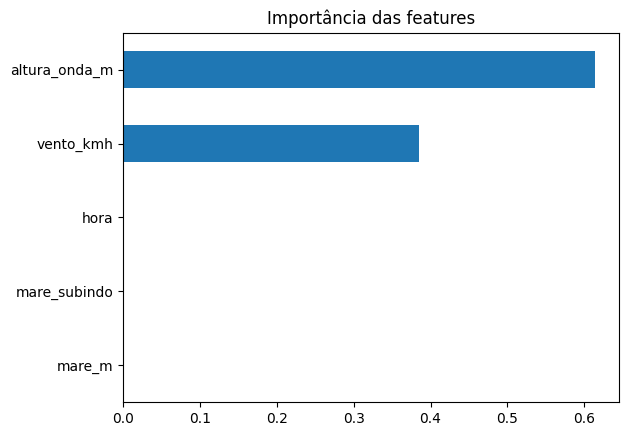

In [8]:
plt.figure(figsize=(14, 6))
plot_tree(arvore, feature_names=FEATURES, class_names=list(arvore.classes_), filled=True, fontsize=8)
plt.show()

pd.Series(arvore.feature_importances_, index=FEATURES).sort_values().plot.barh(title="Importância das features")
plt.show()

Os cortes da árvore são parecidos com os meus limiares: onda em 1,05 e 1,25 m (usei 1,1 e 1,3) e vento em 19,5 e 23,5 km/h (usei 19 e 23). As features importantes são a onda (0,61) e o vento (0,38). Maré e hora não pesam nada, o que faz sentido porque não estão na regra.

## 8. Responder a pergunta

Aplique o modelo na janela inteira e produza a resposta para Felipe e Nicholas:

- Quais os melhores dias da janela de previsão?
- Em média, qual o melhor horário do dia?
- Em que grau essa resposta é uma previsão do mar, e em que grau é apenas a
  sua regra reescrita?

dia
2026-10-14    1.75
2026-10-08    0.92
2026-10-13    0.92
2026-10-12    0.54
2026-10-10    0.50
2026-10-11    0.12
2026-10-09    0.08
Name: nota, dtype: float64


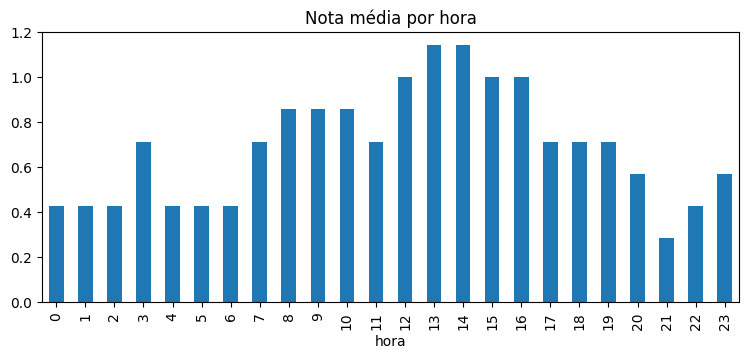

In [9]:
arvore.fit(X, y)
df["previsao"] = arvore.predict(X)
df["nota"] = df["previsao"].map({"ruim": 0, "boa": 1, "otima": 2})

print(df.groupby("dia")["nota"].mean().round(2).sort_values(ascending=False))
df.groupby("hora")["nota"].mean().plot.bar(figsize=(9, 3.5), title="Nota média por hora")
plt.show()

Cada hora recebeu uma nota (0 para ruim, 1 para boa, 2 para ótima) e fiz a média por dia. O melhor dia é 14/10 (nota 1,75), bem acima dos outros: 08/10 e 13/10 (0,92) vêm depois. Os piores são 09 e 11/10. Na média da semana, as melhores horas são 13h e 14h, mas isso vem principalmente do dia 14/10.

## 9. Conclusão e limites

Em texto:

1. A recomendação, em uma frase.
2. O teto deste modelo: ele reproduz a sua heurística, então é tão bom quanto
   ela. O que faria dela uma regra melhor?
3. O que a janela de ~7 dias e o volume de linhas impedem de afirmar.
4. Como você responderia "qual a melhor época do ano para surfar em João
   Pessoa" — que dado faltaria, e como coletá-lo.

1. **Recomendação.** Voltar em 14/10, quando a onda chega a 1,4 m e o vento é mais fraco. A tarde é o melhor período.
2. **Limite do modelo.** Ele só copia a minha regra, então não prevê o mar. A regra seria melhor com limiares de um surfista e com dados como o período da onda.
3. **Limite dos dados.** Só há uma semana de previsão, então não dá para afirmar nada sobre o ano todo, e a previsão pode errar.
4. **Melhor época do ano.** Faltam ondas e vento de vários meses. Eu coletaria a previsão todos os dias por um ano e aplicaria a mesma regra a cada mês.